# True Parameters at 1 PA Model

```python
m1 = 1e6
m2 = 10
a = 0.8 
e0 = 0.4 
xI0 = 1.0
dist = 0.4

qS = xp.pi/4
phiS = 1.0
qK = 1
phiK = xp.pi/3

Phi_phi0 = 0.9
Phi_theta0 = 0.5
Phi_r0 = 0.4

dt = 10.0
T = 0.5

chi2 = 0.0

dev_0_p = 0.0
dev_0_e = 0.0
dev_1_p = 0.0
dev_1_e = 0.0
dev_2_p = 0.0
dev_2_e = 0.0

evolve_1PA = True
evolve_primary = False
evolve_2PA = False
deviation_included = True

p0 = 7.5

best_fit = [13.81561299, 10.00055693,  0.80008266,  7.49954817,  0.39998251, 0.78536073,  0.99998866,  0.90006928,  0.39977347]

In [1]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
from scipy.stats import chi2


from itertools import product
import os
import h5py
from tqdm import tqdm
import pandas as pd

#few utils
from few.utils.utility import get_p_at_t
from few.utils.constants import MTSUN_SI
from few.utils.geodesic import get_fundamental_frequencies
#few trajectory
from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode.flux import SuperKludgeFlux
#few waveform
from few.waveform import FastKerrEccentricEquatorialFlux, GenerateEMRIWaveform
from few.waveform.waveform import SuperKludgeWaveform
from few.utils.constants import YRSID_SI

#sef imports
from stableemrifisher.fisher import StableEMRIFisher
from stableemrifisher.utils import generate_PSD, padding, inner_product
from stableemrifisher.fisher.derivatives import derivative
from stableemrifisher.fisher.stablederivative import StableEMRIDerivative
from stableemrifisher.noise import sensitivity_LWA

#lisa-on-gpu import
from fastlisaresponse import ResponseWrapper  # Response function 

#LISAanalysistools imports
from lisatools.detector import ESAOrbits, EqualArmlengthOrbits #ESAOrbits correspond to esa-trailing-orbits.h5, EqualArmlengthOrbits are equalarmlength-orbits.h5
from lisatools.sensitivity import get_sensitivity, A1TDISens, E1TDISens, T1TDISens
from lisatools.sensitivity import get_sensitivity,CornishLISASens

use_gpu = True
from parismc.sampler import SamplerConfig
from parismc.sampler import Sampler

from smt.sampling_methods import LHS

if not use_gpu:
    
    import few
    
    #tune few configuration
    cfg_set = few.get_config_setter(reset=True)
    
    cfg_set.enable_backends("cpu")
    cfg_set.set_log_level("info");
else:
    pass #let the backend decide for itself

startup


In [2]:
#waveform class setup
waveform_class = SuperKludgeWaveform
max_step_days = 10.0 #max trajectory step size in days
inspiral_kwargs = {
    "err":1e-11, #default = 1e-11
    "max_step_size":max_step_days*24*60*60, #in seconds
}
sum_kwargs = {
    "pad_output": True, # True if expecting waveforms smaller than LISA observation window.
}

waveform_class_kwargs = dict(inspiral_kwargs=inspiral_kwargs,
                              mode_selector_kwargs=dict(mode_selection_threshold=1e-5),
                              sum_kwargs=sum_kwargs,
                              use_gpu=use_gpu)

waveform_generator = GenerateEMRIWaveform
waveform_generator_kwargs = dict(return_list=False)


In [3]:
if(use_gpu):
    xp=cp
else:
    xp=np

best_fit = best_fit = [13.81561299, 10.00055693,  0.80008266,  7.49954817,  0.39998251, 0.78536073,  0.99998866,  0.90006928,  0.39977347]
#logm1_, m2_, a_, p0_, e0_,qS_,phiS_,Phi_phi0_,Phi_r0_,dev0p_,dev0e_ = params[i]
logm1 = best_fit[0]
m1= np.exp(logm1)
m2 = best_fit[1]
a = best_fit[2]
p0= best_fit[3]
e0 = best_fit[4]
xI0 = 1.0
dist = 0.4
qS = best_fit[5]
phiS = best_fit[6]
qK = 1 
phiK = np.pi/3
Phi_phi0 = best_fit[7]
Phi_theta0 =0.5
Phi_r0 = best_fit[8]

dt = 10.0
T = 0.5

chi2 = 0.0

dev_0_p=0.0
dev_0_e=0.0
dev_1_p=0.0
dev_1_e=0.0
dev_2_p=0.0
dev_2_e=0.0
evolve_1PA = False
evolve_primary = False
evolve_2PA = False
deviation_included=True


print(use_gpu)

pars_list_com = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,\
             chi2,evolve_1PA,evolve_primary,evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]

add_param_args={"chi2":chi2,"evolve_1PA":evolve_1PA,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,"deviation_included":deviation_included,"dev0p":dev_0_p,
"dev0e":dev_0_e,"dev1p":dev_1_p,"dev1e":dev_1_e,"dev2p":dev_2_p,"dev2e":dev_2_e}

param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0']
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]

emri_kwargs = {"T":T, "dt":dt}

param_names_com = ['m1','m2','a','p0','e0','xI0','dist','qS','phiS','qK','phiK','Phi_phi0','Phi_theta0','Phi_r0',"chi2",
               "evolve_1PA","evolve_primary","evolve_2PA","deviation_included","dev0p","dev0e","dev1p","dev1e","dev2p","dev2e"]

True


In [4]:
der_order = 8
Ndelta=16
sef = StableEMRIFisher(waveform_class=waveform_class, 
                       waveform_class_kwargs=waveform_class_kwargs,
                       waveform_generator=waveform_generator,
                       waveform_generator_kwargs=waveform_generator_kwargs,
                       stats_for_nerds = True, use_gpu = use_gpu,
                       deriv_type='stable',
                       noise_model=get_sensitivity,
                       noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
                       channels=["A","E"],
                       T = T, dt = dt,
                       stability_plot = False,
                       der_order = der_order, Ndelta = Ndelta,
                       plunge_check=True, return_derivatives=False
                       )
                   

SNR = sef.SNRcalc_SEF(*pars_list_com,**emri_kwargs,use_gpu=use_gpu)
print("SNR: ", SNR)

waveform shape:  (2, 1577908)
wave ndim: 2
Computing SNR for parameters: (np.float64(1000102.437282066), 10.00055693, 0.80008266, 7.49954817, 0.39998251, 1.0, 0.4, 0.78536073, 0.99998866, 1, 1.0471975511965976, 0.90006928, 0.5, 0.39977347, 0.0, False, False, False, True, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0)
SNR:  72.3917301210958


Body is not plunging, Fisher should be stable.
waveform shape:  (2, 1577908)
wave ndim: 2
Computing SNR for parameters: (np.float64(1000102.437282066), 10.00055693, 0.80008266, 7.49954817, 0.39998251, 1.0, 0.4, 0.78536073, 0.99998866, 1, 1.0471975511965976, 0.90006928, 0.5, 0.39977347, 0.0, False, False, False, True, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0)
Waveform Generated. SNR: 72.3917301210958
calculating stable deltas...
Gamma_ii for m1: 537.3381179298292
Gamma_ii for m1: 537.3381183080656
Gamma_ii for m1: 537.3381183115363
Gamma_ii for m1: 537.3381183153623
Gamma_ii for m1: 537.3381183112477
Gamma_ii for m1: 537.33811830612
Gamma_ii for m1: 537.3381183510436
Gamma_ii for m1: 537.3381180973064
Gamma_ii for m1: 537.3381186611293
Gamma_ii for m1: 537.3381180901175
Gamma_ii for m1: 537.3381215433553
Gamma_ii for m1: 537.3381193388625
Gamma_ii for m1: 537.3381195880863
Gamma_ii for m1: 537.3380948169038
Gamma_ii for m1: 537.3381490486345
Gamma_ii for m1: 537.338209834953
[np.float64(7.039077208

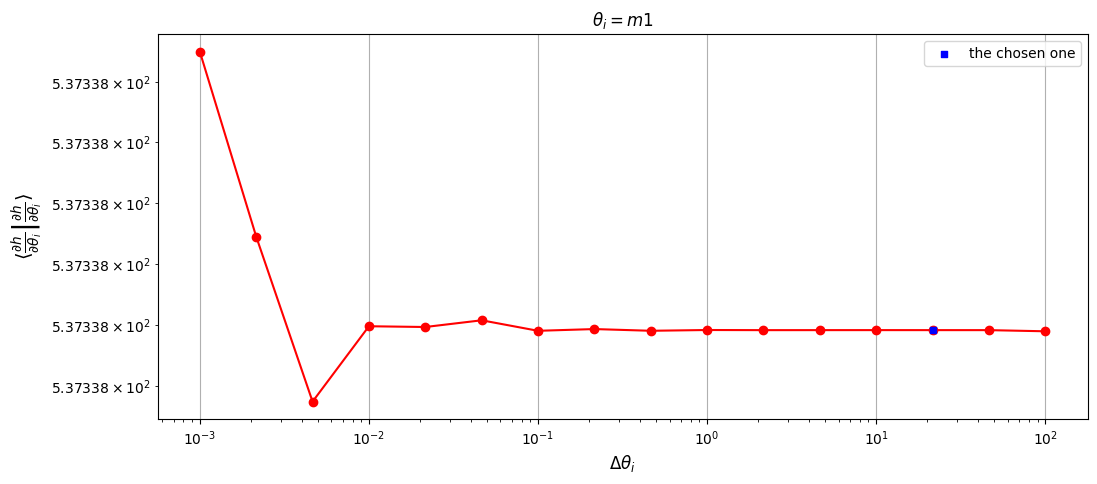

Gamma_ii for m2: 45250405034.120384
Gamma_ii for m2: 45250405037.818436
Gamma_ii for m2: 45250405032.86243
Gamma_ii for m2: 45250405037.10377
Gamma_ii for m2: 45250405023.38918
Gamma_ii for m2: 45250404964.47028
Gamma_ii for m2: 45250405056.71059
Gamma_ii for m2: 45250404975.7226
Gamma_ii for m2: 45250405456.69267
Gamma_ii for m2: 45250404260.27312
Gamma_ii for m2: 45250405701.00869
Gamma_ii for m2: 45250408016.09994
Gamma_ii for m2: 45250416931.52989
Gamma_ii for m2: 45250432669.999725
Gamma_ii for m2: 45250427666.08796
Gamma_ii for m2: 45250334001.126236
[np.float64(8.17241624587899e-11), np.float64(1.0952407845926651e-10), np.float64(9.373044580991659e-11), np.float64(3.0308202420502305e-10), np.float64(1.302063475064914e-09), np.float64(2.03844148851153e-09), np.float64(1.7897736770988972e-09), np.float64(1.0629077574687609e-08), np.float64(2.6439974962045594e-08), np.float64(3.183917471004742e-08), np.float64(5.1161776192932724e-08), np.float64(1.9702426097021562e-07), np.float64(

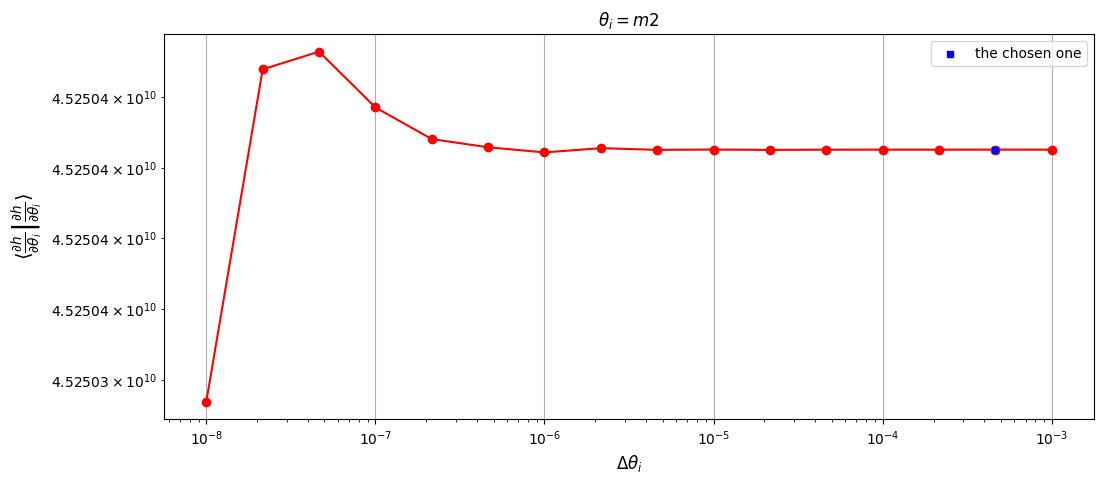

Gamma_ii for a: 2537655381801.059
Gamma_ii for a: 2537655736252.509
Gamma_ii for a: 2537653604844.8784
Gamma_ii for a: 2537656893032.191
Gamma_ii for a: 2537661102949.53
Gamma_ii for a: 2537679743226.193
Gamma_ii for a: 2537652318062.1616
Gamma_ii for a: 2537571150634.2954
Gamma_ii for a: 2537402098020.0674
Gamma_ii for a: 2537330418550.6475
Gamma_ii for a: 2537712656521.9307
Gamma_ii for a: 2538066354987.8955
Gamma_ii for a: 2537671087970.958
Gamma_ii for a: 2538262041470.2383
Gamma_ii for a: 2543666166996.6504
Gamma_ii for a: 2537809200640.143
[np.float64(1.39676727872658e-07), np.float64(8.399127549567122e-07), np.float64(1.2957572481640797e-06), np.float64(1.6589753982413138e-06), np.float64(7.345401527849316e-06), np.float64(1.0807297688515816e-05), np.float64(3.198626680710891e-05), np.float64(6.662429039525858e-05), np.float64(2.8249954714556262e-05), np.float64(0.0001506230306653711), np.float64(0.00013935745425636462), np.float64(0.00015575975106117598), np.float64(0.000232818

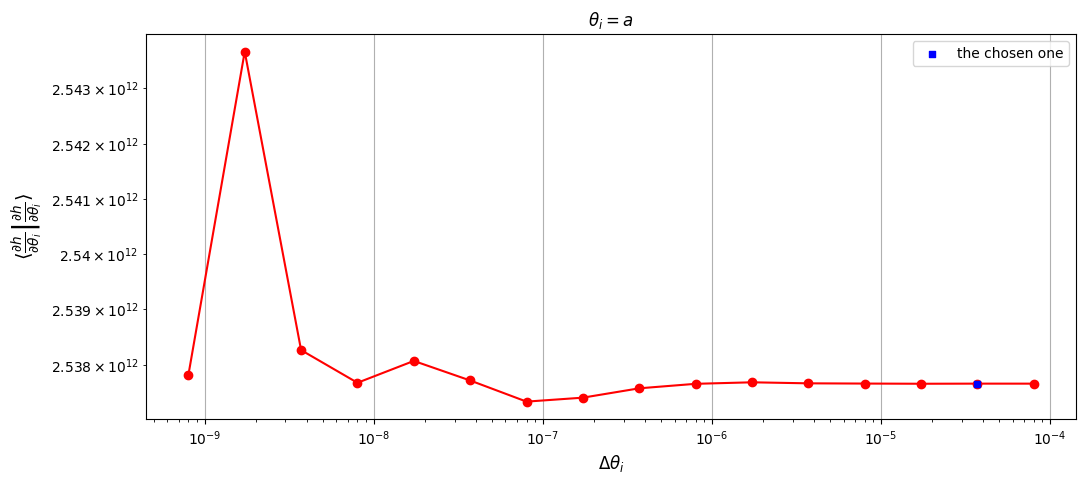

Gamma_ii for p0: 20571711600256.883
Gamma_ii for p0: 20571711893181.83
Gamma_ii for p0: 20571711948821.535
Gamma_ii for p0: 20571711177428.65
Gamma_ii for p0: 20571713190856.066
Gamma_ii for p0: 20571701483533.586
Gamma_ii for p0: 20571685212588.93
Gamma_ii for p0: 20571723144594.184
Gamma_ii for p0: 20571702535712.297
Gamma_ii for p0: 20571599166029.098
Gamma_ii for p0: 20571796726420.19
Gamma_ii for p0: 20572828444244.375
Gamma_ii for p0: 20571435710439.24
Gamma_ii for p0: 20568736920103.035
Gamma_ii for p0: 20581903017151.45
Gamma_ii for p0: 20569377291760.35
[np.float64(1.4239210953055656e-08), np.float64(2.704670723062373e-09), np.float64(3.749775019032568e-08), np.float64(9.787358978267787e-08), np.float64(5.690984039331778e-07), np.float64(7.909388311217657e-07), np.float64(1.84389051842135e-06), np.float64(1.0018073054936464e-06), np.float64(5.024873485281506e-06), np.float64(9.603458255059695e-06), np.float64(5.014953714214419e-05), np.float64(6.770231425461269e-05), np.float6

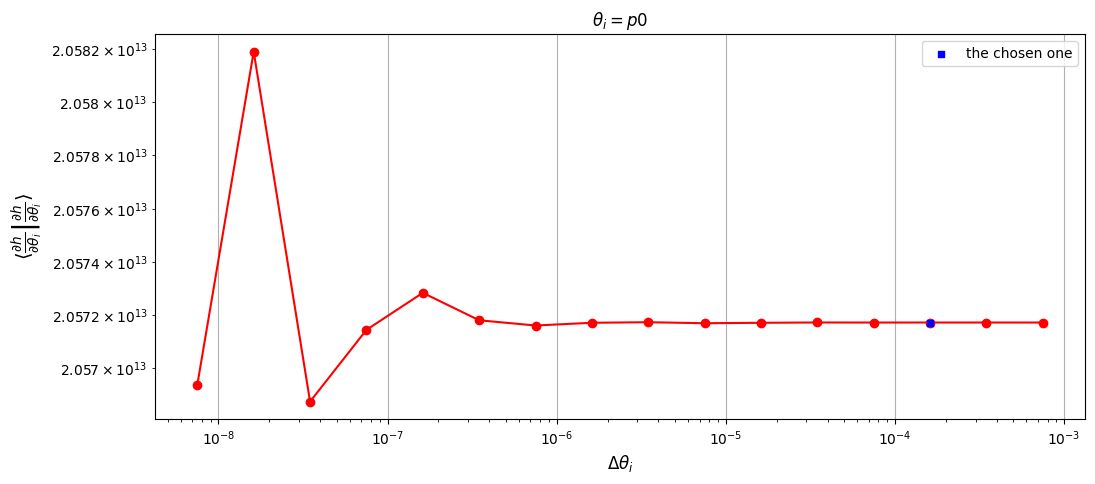

Gamma_ii for e0: 335326972153817.94
Gamma_ii for e0: 335326945783102.0
Gamma_ii for e0: 335326905306339.6
Gamma_ii for e0: 335327100647717.3
Gamma_ii for e0: 335326752461641.1
Gamma_ii for e0: 335326436716470.8
Gamma_ii for e0: 335327424835006.5
Gamma_ii for e0: 335329137953422.25
Gamma_ii for e0: 335325919244289.4
Gamma_ii for e0: 335340932594450.0
Gamma_ii for e0: 335329537098269.4
Gamma_ii for e0: 335342899050468.75
Gamma_ii for e0: 335285557685624.3
Gamma_ii for e0: 335359144193770.6
Gamma_ii for e0: 336035396706346.1
Gamma_ii for e0: 334730135866613.94
[np.float64(7.864180397407505e-08), np.float64(1.2070836468675917e-07), np.float64(5.825397867043221e-07), np.float64(1.038348636461178e-06), np.float64(9.41605360449026e-07), np.float64(2.9467274744190425e-06), np.float64(5.108766945233238e-06), np.float64(9.598748406114493e-06), np.float64(4.4770407371597664e-05), np.float64(3.3982977697802723e-05), np.float64(3.984563930594529e-05), np.float64(0.00017102247183042345), np.float64(

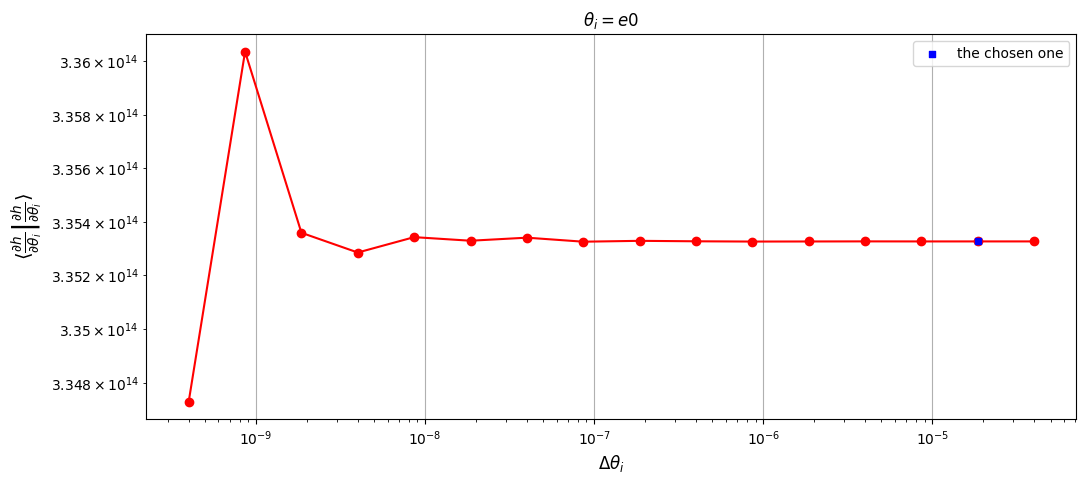

Gamma_ii for qS: 16129.718027479215
Gamma_ii for qS: 16129.718049593017
Gamma_ii for qS: 16129.718049641438
Gamma_ii for qS: 16129.718049641513
Gamma_ii for qS: 16129.71804964156
Gamma_ii for qS: 16129.71804964109
Gamma_ii for qS: 16129.718049643638
Gamma_ii for qS: 16129.718049643541
Gamma_ii for qS: 16129.718049639536
Gamma_ii for qS: 16129.718049641242
Gamma_ii for qS: 16129.718049609684
Gamma_ii for qS: 16129.718049649095
Gamma_ii for qS: 16129.71804965722
Gamma_ii for qS: 16129.718049559717
Gamma_ii for qS: 16129.718049393856
Gamma_ii for qS: 16129.718047714035
[np.float64(1.3709974060235372e-09), np.float64(3.002005228694441e-12), np.float64(4.6236744694392e-15), np.float64(2.9320862489126552e-15), np.float64(2.9208089941092303e-14), np.float64(1.5799433979715773e-13), np.float64(5.976945045859678e-15), np.float64(2.48325150773326e-13), np.float64(1.0578065005692788e-13), np.float64(1.956490935864853e-12), np.float64(2.4433300257273812e-12), np.float64(5.037549720723121e-13), np.

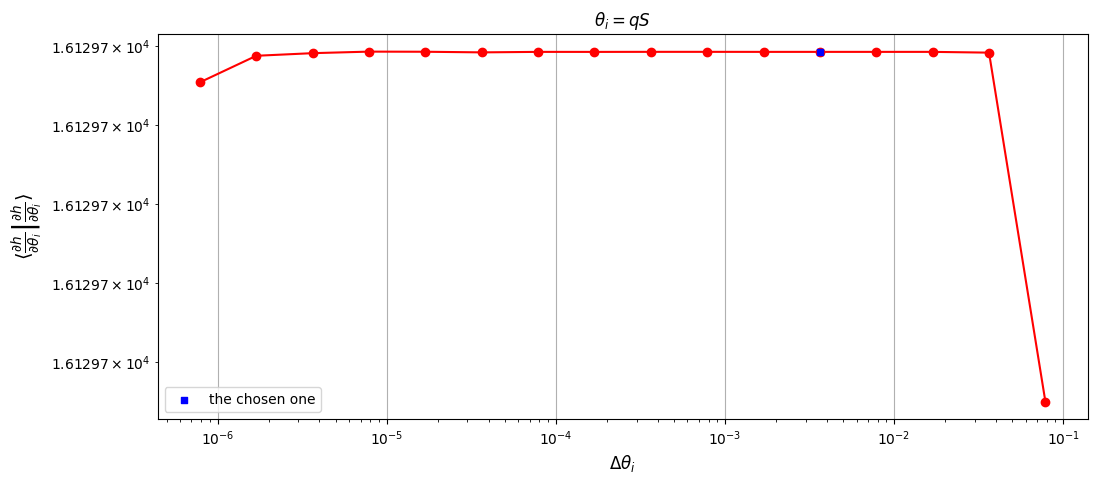

Gamma_ii for phiS: 310465.04900688305
Gamma_ii for phiS: 310465.0490022008
Gamma_ii for phiS: 310465.0490021904
Gamma_ii for phiS: 310465.0490021904
Gamma_ii for phiS: 310465.0490021904
Gamma_ii for phiS: 310465.0490021904
Gamma_ii for phiS: 310465.0490021905
Gamma_ii for phiS: 310465.0490021904
Gamma_ii for phiS: 310465.04900219035
Gamma_ii for phiS: 310465.0490021902
Gamma_ii for phiS: 310465.0490021901
Gamma_ii for phiS: 310465.0490021906
Gamma_ii for phiS: 310465.04900218995
Gamma_ii for phiS: 310465.049002193
Gamma_ii for phiS: 310465.0490021866
Gamma_ii for phiS: 310465.0490022005
[np.float64(1.508151228806126e-11), np.float64(3.3372399488755653e-14), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(3.749707807725353e-16), np.float64(3.7497078077253544e-16), np.float64(1.8748539038626775e-16), np.float64(5.624561711588036e-16), np.float64(1.874853903862679e-16), np.float64(1.499883123090141e-15), np.float64(2.062339294248948e-15), np.float64(9.749240300085841e-15), n

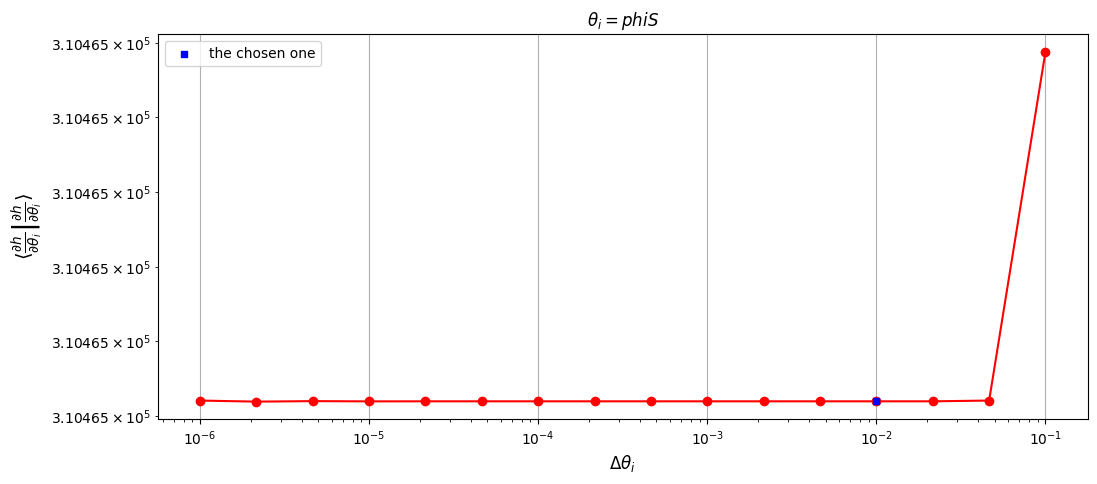

stable deltas: {'m1': 21.546553844659197, 'm2': 0.0004641847337619687, 'a': 3.713654740623215e-05, 'p0': 0.0001615728673701314, 'e0': 1.8565543520564136e-05, 'qS': 0.0036453215947259815, 'phiS': 0.009999886600000002, 'Phi_phi0': 0.0, 'Phi_r0': 0.0}
Time taken to compute stable deltas is 112.43414378166199 seconds
calculating Fisher matrix...
Finished derivatives
Calculated Fisher is *atleast* positive-definite.
Time taken to compute FM is 7.4370810985565186 seconds


In [5]:
param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0']
pars_list = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]

param_dict = {
    'm1': m1,
    'm2': m2,
    'a': a,
    'p0': p0,
    'e0': e0,
    'xI0': xI0,
    'dist': dist,
    'qS': qS,
    'phiS': phiS,
    'qK': qK,
    'phiK': phiK,
    'Phi_phi0': Phi_phi0,
    'Phi_theta0': Phi_theta0,
    'Phi_r0': Phi_r0
}


Fisher = sef(wave_params = param_dict,param_names=param_names, add_param_args=add_param_args,
            live_dangerously = False, stability_plot = True,der_order = der_order, Ndelta = Ndelta,return_derivatives=True
            )


In [11]:
def logmasstransform(Fisher, m1, index_of_m1 = 0):    
    J = np.eye(len(Fisher))
    J[index_of_m1,index_of_m1] = m1
    
    return J.T@Fisher@J
fisher_=logmasstransform(Fisher[-1], m1, index_of_m1 = 0)
cov=np.linalg.inv(fisher_)
std= np.sqrt(np.diag(cov))
params_truth_in = np.array([np.log(1e6), 10, 0.8, 7.5, 0.4, np.pi/4, 1.0,  0.9,0.4])

In [12]:
pd.DataFrame(fisher_)

,0,1,2,3,4,5,6,7,8
0,5.374482e+14,-4.796343e+12,2.550542e+13,1.050484e+14,4.228415e+14,-2.390039e+09,1.102575e+10,-2.891690e+09,-2.544605e+09
1,-4.796343e+12,4.525041e+10,-2.623243e+11,-9.435795e+11,-3.693084e+12,1.927978e+07,-8.893675e+07,2.332569e+07,1.942287e+07
2,2.550542e+13,-2.623243e+11,2.537656e+12,5.213210e+12,1.896929e+13,-1.081587e+08,4.992017e+08,-1.311353e+08,-4.628627e+07
3,1.050484e+14,-9.435795e+11,5.213210e+12,2.057171e+13,8.245449e+13,-4.660528e+08,2.150040e+09,-5.639201e+08,-4.843657e+08
4,4.228415e+14,-3.693084e+12,1.896929e+13,8.245449e+13,3.353269e+14,-1.950083e+09,8.996294e+09,-2.359421e+09,-2.111025e+09
5,-2.390039e+09,1.927978e+07,-1.081587e+08,-4.660528e+08,-1.950083e+09,1.612972e+04,-6.707202e+04,1.759507e+04,1.503780e+04
6,1.102575e+10,-8.893675e+07,4.992017e+08,2.150040e+09,8.996294e+09,-6.707202e+04,3.104650e+05,-8.119007e+04,-6.936626e+04
7,-2.891690e+09,2.332569e+07,-1.311353e+08,-5.639201e+08,-2.359421e+09,1.759507e+04,-8.119007e+04,2.130207e+04,1.818370e+04
8,-2.544605e+09,1.942287e+07,-4.628627e+07,-4.843657e+08,-2.111025e+09,1.503780e+04,-6.936626e+04,1.818370e+04,2.090233e+04


In [13]:
from scipy.stats import chi2
def plot_confidence_ellipse(ax, mean, cov, i, j, levels=[0.90, 0.99]):
    """
    Plots 2D 90% and 99% confidence ellipses onto ax.
    mean: (D,) best-fit vector
    cov:  (D,D) covariance
    i,j: indices of parameters
    """
    # Extract 2x2 sub-covariance
    cov2 = cov[np.ix_([i, j], [i, j])]
    mean2 = mean[[i, j]]
    
    # Eigen decomposition
    eigvals, eigvecs = np.linalg.eigh(cov2)
    order = np.argsort(eigvals)[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    theta = np.linspace(0, 2*np.pi, 400)

    for p in levels:
        chi2_val = chi2.ppf(p, df=2)
        r1 = np.sqrt(eigvals[0] * chi2_val)
        r2 = np.sqrt(eigvals[1] * chi2_val)
        
        ellipse = np.vstack([r1*np.cos(theta), r2*np.sin(theta)])
        ellipse = eigvecs @ ellipse + mean2[:, None]

        ax.plot(ellipse[0], ellipse[1], label=f"{int(p*100)}%", lw=1)


# --------------------------------------------------------------------
# Main triangle plot function (WITH LEGEND)
# --------------------------------------------------------------------
def triangle_plot(best_fit, cov, param_truth=None, labels=None,levels=[0.90, 0.99]):
    D = len(best_fit)
    if labels is None:
        labels = [f"p{i}" for i in range(D)]

    fig, axes = plt.subplots(D, D, figsize=(2.2*D, 2.2*D))
    
    legend_ax = axes[-1, -1]  # bottom-right panel for legend only
    legend_handles = []       # store handles for legend

    for i in range(D):
        for j in range(D):

            ax = axes[i, j]

            if i < j:
                ax.axis("off")
                continue

            # ==========================
            # Diagonal panels
            # ==========================
            if i == j:
                sigma = np.sqrt(cov[i, i])
                x = np.linspace(best_fit[i] - 4*sigma,
                                best_fit[i] + 4*sigma, 300)
                y = np.exp(-0.5*((x - best_fit[i])/sigma)**2)

                ax.plot(x, y, lw=1.5)

                if param_truth is not None:
                    line_truth = ax.axvline(param_truth[i], color='red', linestyle='--', lw=1)

                ax.set_yticks([])
                ax.set_xlabel(labels[i])

            # ==========================
            # Off-diagonal panels
            # ==========================
            else:
                # Ellipses
                plot_confidence_ellipse(ax, best_fit, cov, j, i,levels=levels)

                # Best-fit point
                bestfit_handle = ax.scatter(best_fit[j], best_fit[i],
                                            color="black", s=12, label="Best-fit")

                # Truth point
                if param_truth is not None:
                    truth_handle = ax.scatter(param_truth[j], param_truth[i],
                                              color="red", marker="x", s=30,
                                              label="Param truth")

                ax.set_xlabel(labels[j])
                ax.set_ylabel(labels[i])

                # Collect handles only once (avoid duplicates)
                if i == D-1 and j == 0:
                    # ellipse handles
                    for item in ax.get_lines():
                        if "10%" in item.get_label() or "90%" in item.get_label():
                            legend_handles.append(item)
                    legend_handles.append(bestfit_handle)
                    if param_truth is not None:
                        legend_handles.append(truth_handle)

    # Add the legend to bottom-right subplot
    legend_ax.legend(handles=legend_handles, loc="upper right", fontsize=9)
    legend_ax.axis("off")  # hide this subplot except for legend

    plt.tight_layout()
    plt.show()


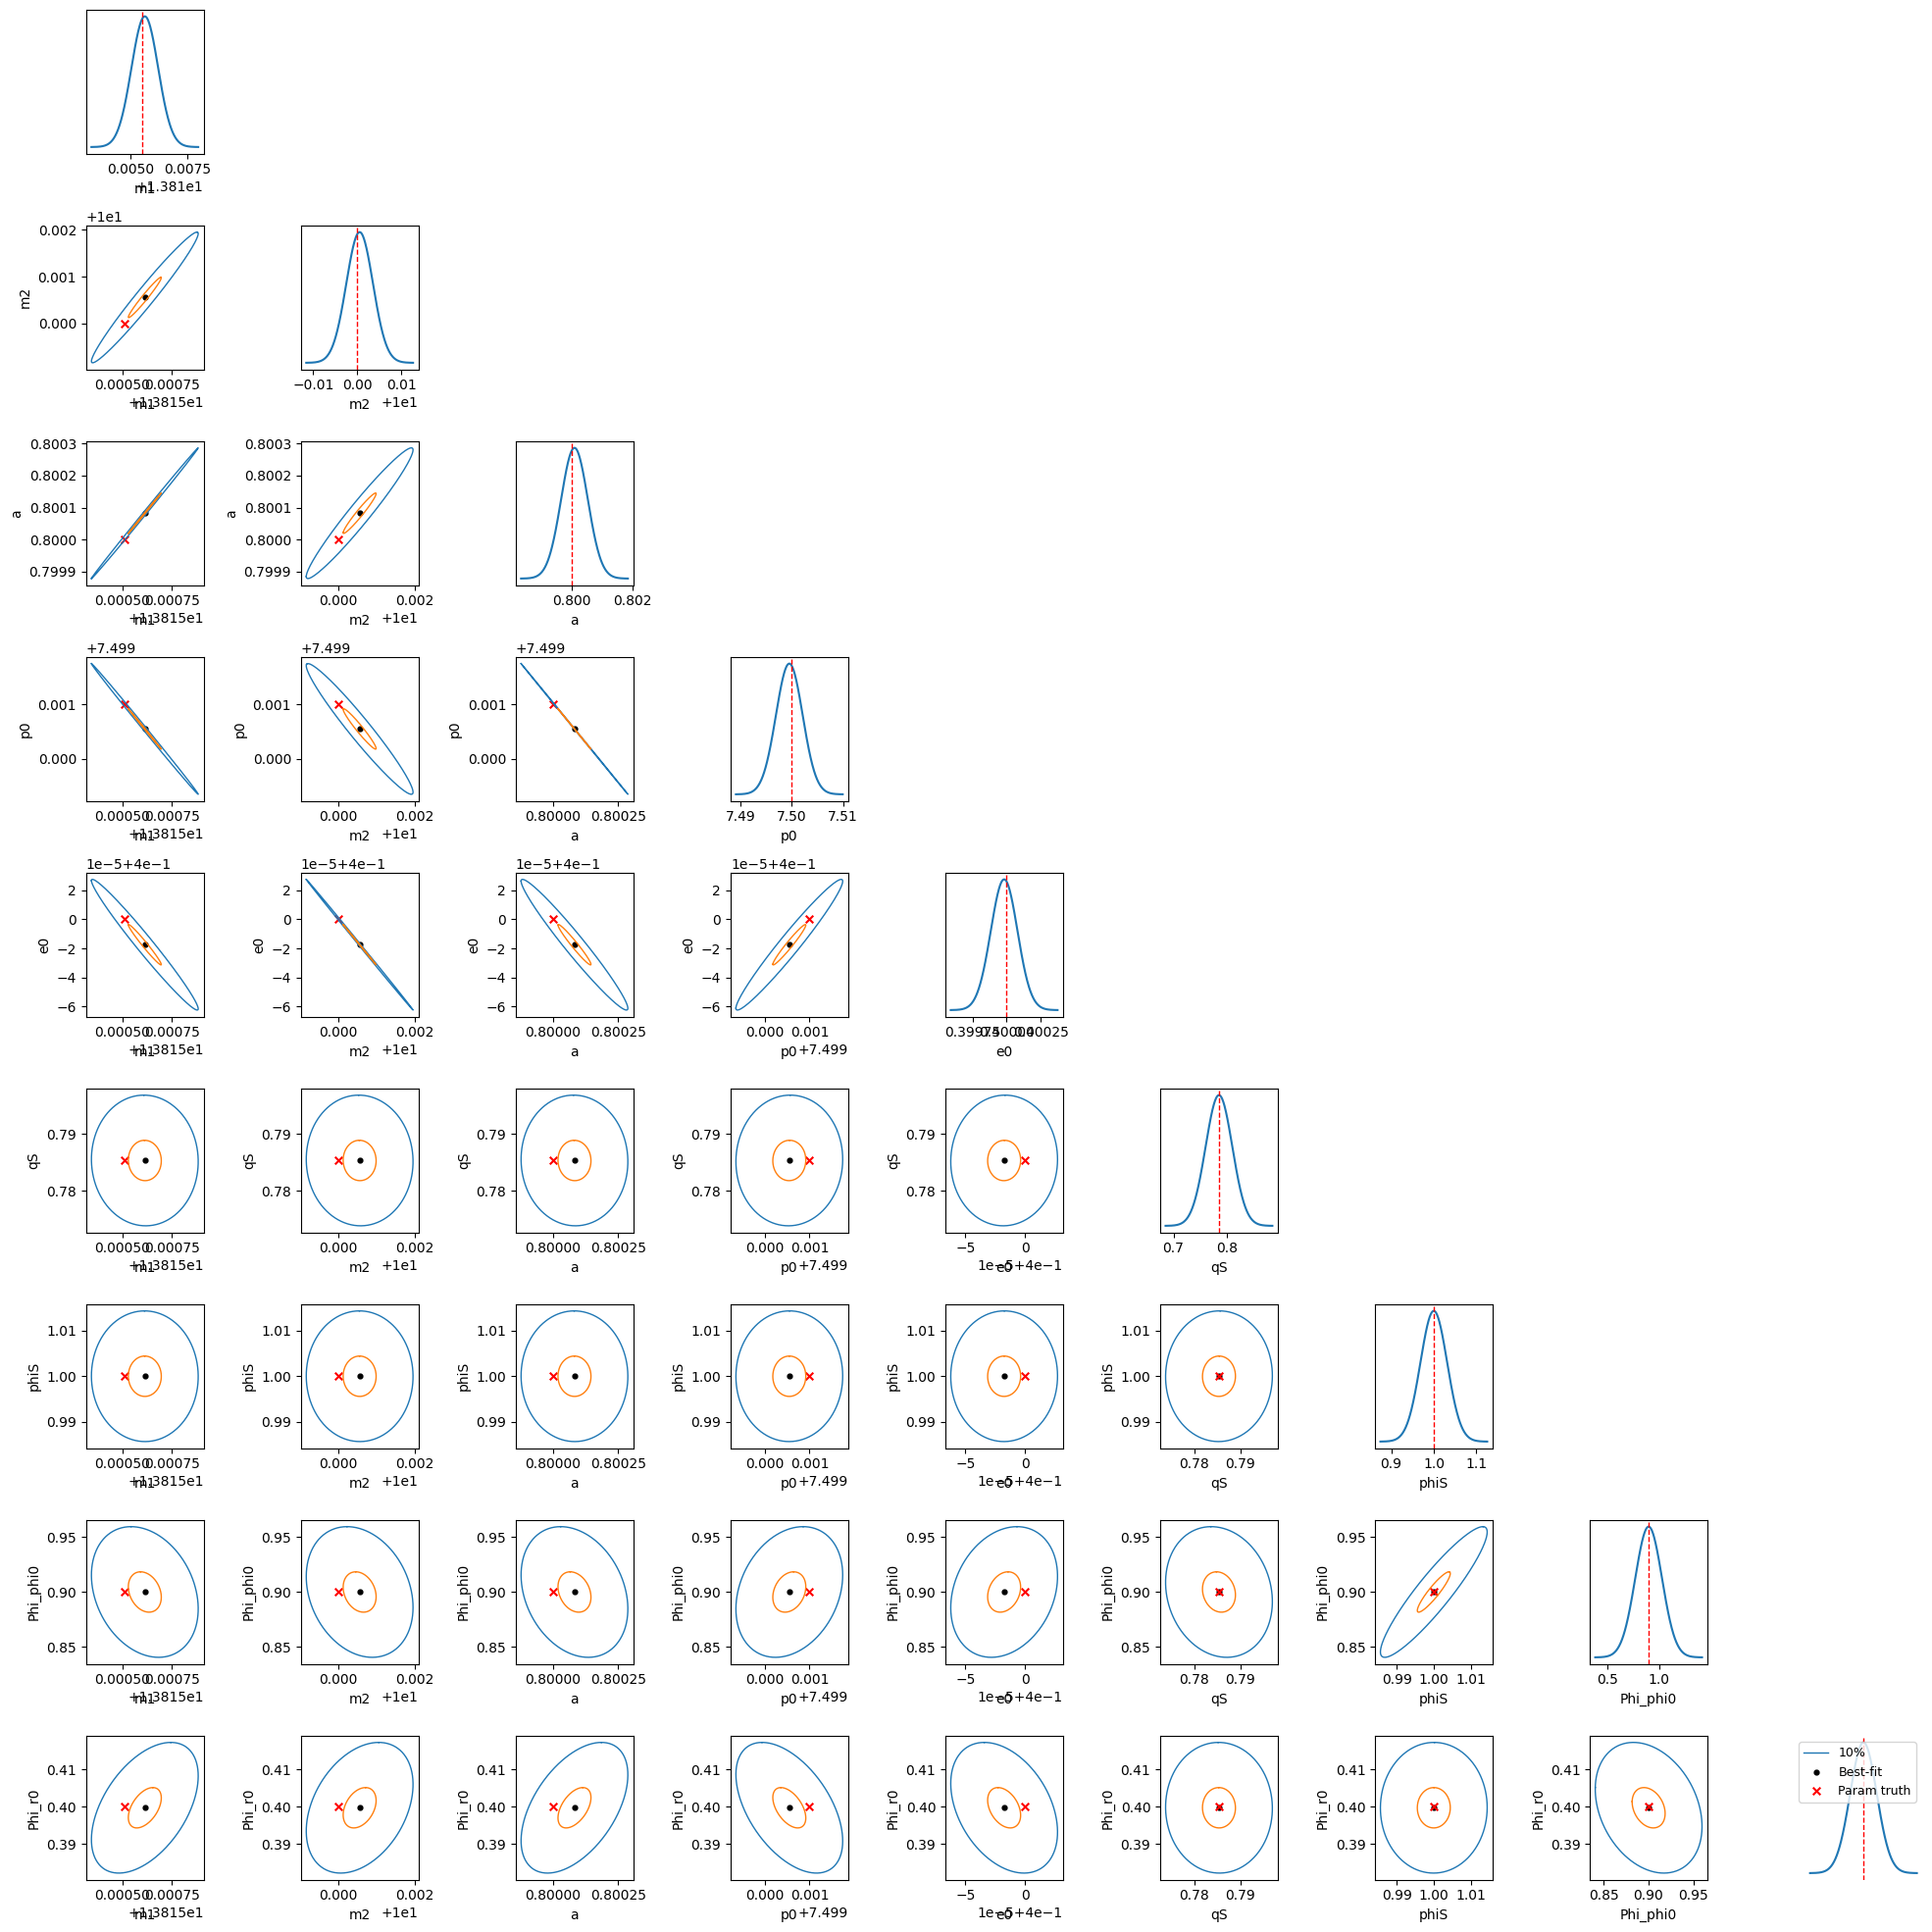

In [16]:
labels = param_names
triangle_plot(np.array(best_fit), cov, np.array(params_truth_in), labels,levels=[0.1, 0.01])


In [17]:
# True waveform with 1PA order
m1_true = 1e6
m2_true = 10
a_true = 0.8 
e0_true = 0.4 # 0.6 just spin first
xI0_true = 1.0
dist_true = 0.4
qS_true = xp.pi/4
phiS_true = 1.0
qK_true = 1 
phiK_true = xp.pi/3
Phi_phi0_true = 0.9
Phi_theta0_true =0.5
Phi_r0_true = 0.4
p0_true=7.5
chi2 = 0.0
dev_0_p_true=0.0
dev_0_e_true=0.0

evolve_1PA_true = True
evolve_primary = False
evolve_2PA = False
deviation_included=True

superkludge_wave = GenerateEMRIWaveform(SuperKludgeWaveform,\
                                    sum_kwargs=sum_kwargs,\
                                    return_list=True,
                                    mode_selector_kwargs=dict(mode_selection_threshold=1e-5),
                                    inspiral_kwargs=inspiral_kwargs,
                                    use_gpu=use_gpu)

add_args = [chi2, evolve_1PA_true, evolve_primary, evolve_2PA,deviation_included,dev_0_p_true,dev_0_e_true,0,0,0,0]
waveform_true = superkludge_wave(m1_true, m2_true, a_true, p0_true, e0_true, xI0_true, dist_true, qS_true, phiS_true, qK_true, phiK_true, Phi_phi0_true, Phi_theta0_true, Phi_r0_true, *add_args, dt=dt, T=T)
waveform_true= xp.asarray(waveform_true)
fisher_derivs = xp.array(Fisher[0])
fisher_exact = xp.array(Fisher[-1])


In [18]:
# baseline check - 0PA model at true parameters
evolve_1PA_approx = False
add_args = [chi2, evolve_1PA_approx, evolve_primary, evolve_2PA,deviation_included,dev_0_p_true,dev_0_e_true,dev_1_p,dev_1_e,dev_2_p,dev_2_e]
waveform_approx = superkludge_wave(m1_true, m2_true, a_true, p0_true, e0_true, xI0_true, dist_true, qS_true, phiS_true, qK_true, phiK_true, Phi_phi0_true, Phi_theta0_true, Phi_r0_true, *add_args, dt=dt, T=T)
waveform_approx= xp.asarray(waveform_approx)

In [19]:
# waveform at best fit parameters with 0PA calaculated during fisher calculation
waveform_best_fit=sef.waveform
waveform_best_fit= xp.asarray(waveform_best_fit)

# waveform analysis and p0 evolution 

In [20]:
from few.utils.utility import ( 
    get_mismatch, 
    get_m2_at_t, 
    get_p_at_t, 
    )

from few.utils.geodesic import (
    get_fundamental_frequencies,
    get_separatrix,
    get_kerr_geo_constants_of_motion,
    ELQ_to_pex,
    )
SK_traj = EMRIInspiral(func=SuperKludgeFlux)
#get_p_at_t may fail with SuperKludge, especially with lower eccentricities, so we use KerrEccEq to generate p0 
add_args = [chi2, evolve_1PA_true, evolve_primary, evolve_2PA,deviation_included,dev_0_p_true,dev_0_e_true,dev_1_p,dev_1_e,dev_2_p,dev_2_e]
p_sep = get_separatrix(a_true, e0_true, xI0_true)
p0_should = get_p_at_t(traj_module=SK_traj, t_out=0.5, traj_args=[m1_true, m2_true, a_true, e0_true, xI0_true, *add_args])
print('should take p0 around for for true waveform: ', p0_should+0.1)
print('separatrix p: ', p_sep)

should take p0 around for for true waveform:  6.439843289124535
separatrix p:  3.3636344376256564


# P evolution is done considering true waveform (1PA)


[0.0, True, False, False, True, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


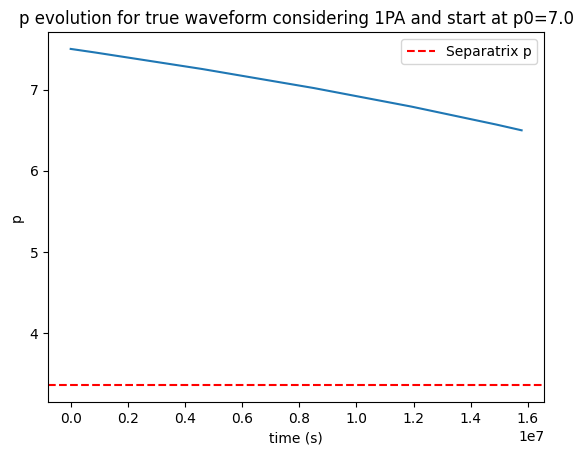

In [21]:
from scipy.interpolate import CubicSpline
add_args = [chi2, evolve_1PA_true, evolve_primary, evolve_2PA,deviation_included,dev_0_p_true,dev_0_e_true,dev_1_p,dev_1_e,dev_2_p,dev_2_e]
print(add_args) 
t_evol, p_evol, e_evol, x2_evol, pp2_evol, pt2_evol, pr2_evol, _, _ = SK_traj(m1_true, m2_true, a_true, p0_true, e0_true, xI0_true, *add_args,
                                               Phi_phi0=Phi_phi0_true, Phi_theta0=Phi_theta0_true, Phi_r0=Phi_r0_true, T=T, dt=dt)
p_evolution = CubicSpline(t_evol, p_evol)(t_evol)
plt.plot(t_evol, p_evolution)
plt.title('p evolution for true waveform considering 1PA and start at p0=7.0')
plt.xlabel('time (s)')
plt.ylabel('p')
plt.axhline(p_sep, color='red', linestyle='--', label='Separatrix p')
plt.legend()
plt.show()

# Waveform Visualization

# Overlap and mismatch

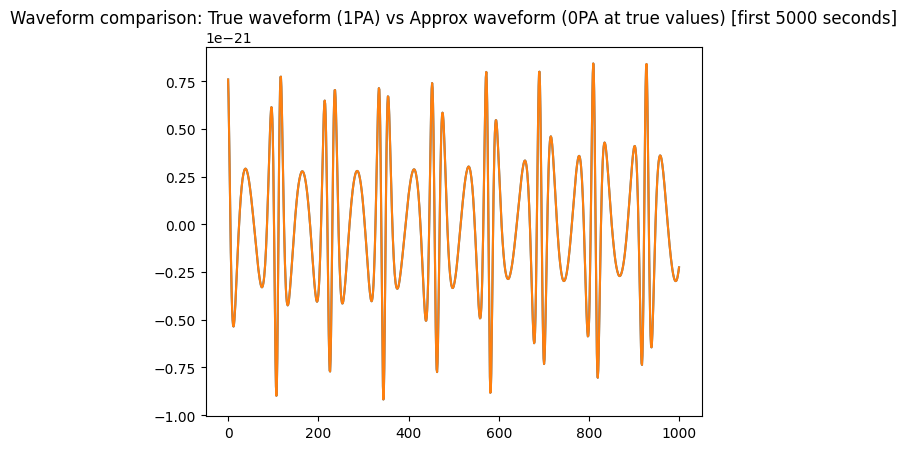

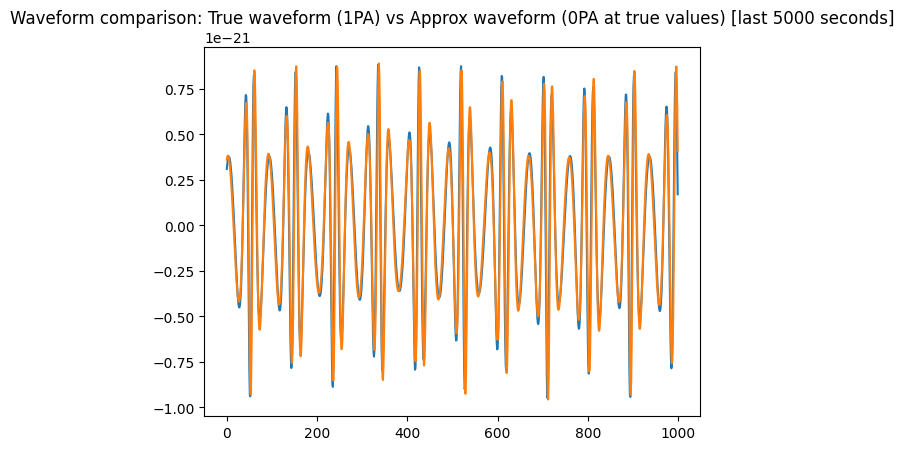

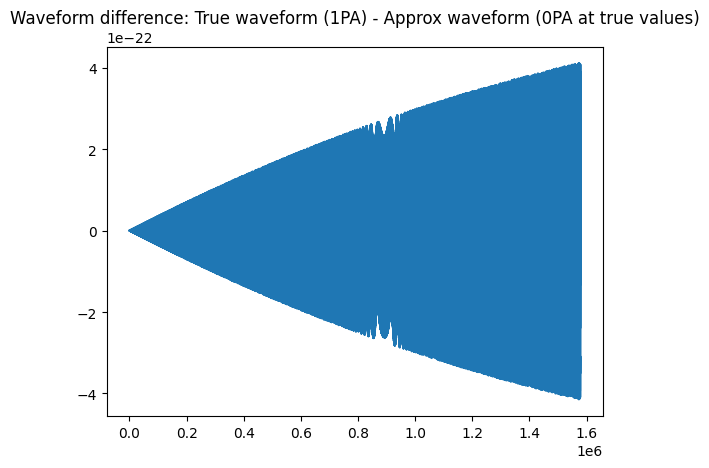

In [22]:
plt.plot(waveform_true[0][0:1000].get())
plt.plot(waveform_approx[0][0:1000].get())
plt.title('Waveform comparison: True waveform (1PA) vs Approx waveform (0PA at true values) [first 5000 seconds]')
plt.show()

plt.plot(waveform_true[0][-1000:].get())
plt.plot(waveform_approx[0][-1000:].get())
plt.title('Waveform comparison: True waveform (1PA) vs Approx waveform (0PA at true values) [last 5000 seconds]')
plt.show()
# waveform_approx
# waveform_best_fit
plt.plot((waveform_true[0]-waveform_approx[0]).get())
plt.title('Waveform difference: True waveform (1PA) - Approx waveform (0PA at true values)')
plt.show()

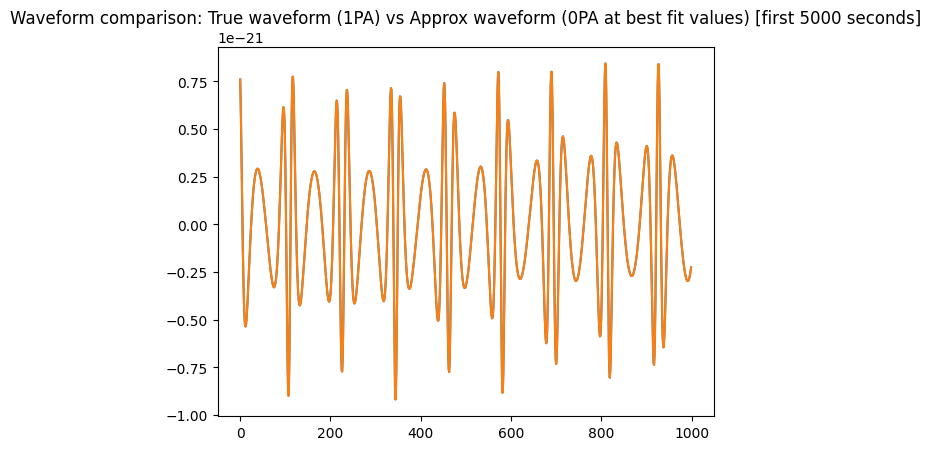

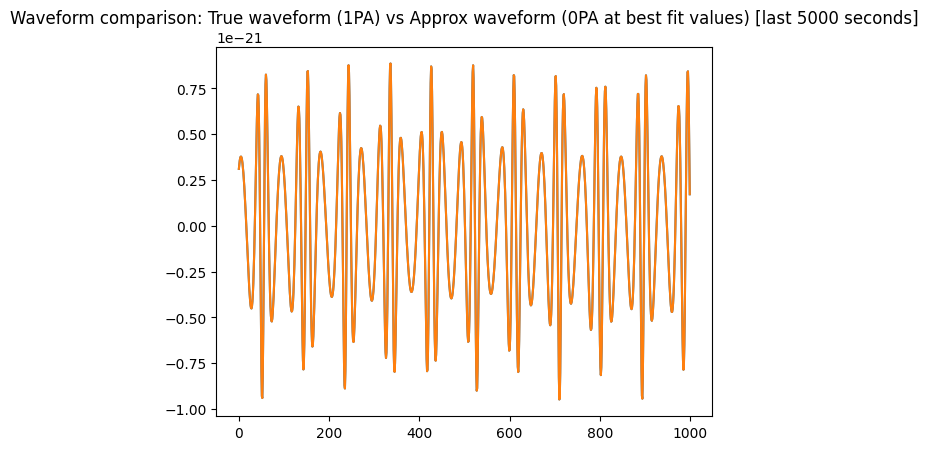

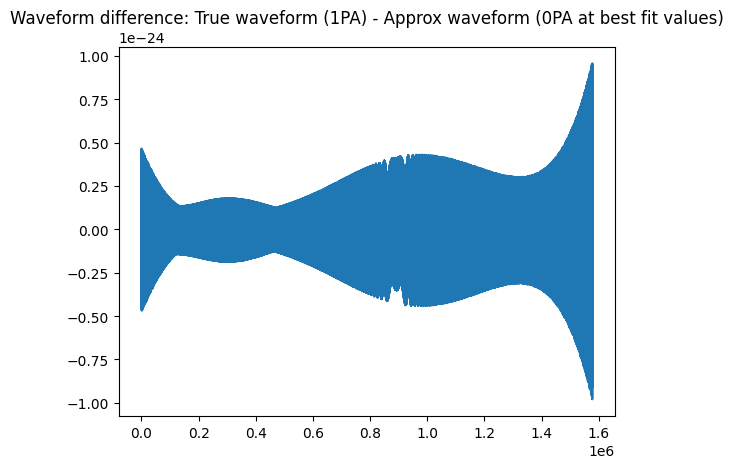

In [23]:
plt.plot(waveform_true[0][0:1000].get())
plt.plot(waveform_best_fit[0][0:1000].get())
plt.title('Waveform comparison: True waveform (1PA) vs Approx waveform (0PA at best fit values) [first 5000 seconds]')
plt.show()

plt.plot(waveform_true[0][-1000:].get())
plt.plot(waveform_best_fit[0][-1000:].get())
plt.title('Waveform comparison: True waveform (1PA) vs Approx waveform (0PA at best fit values) [last 5000 seconds]')
plt.show()
# waveform_approx
# waveform_best_fit
plt.plot((waveform_true[0]-waveform_best_fit[0]).get())
plt.title('Waveform difference: True waveform (1PA) - Approx waveform (0PA at best fit values)')
plt.show()

In [24]:
PSD=generate_PSD(waveform_true,dt,use_gpu=use_gpu,
                noise_PSD=get_sensitivity,
                noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
                channels=["A","E"])
diff_inner_bf=inner_product(waveform_best_fit,waveform_true,PSD,dt,use_gpu=use_gpu)
norm_true=np.sqrt(inner_product(waveform_true,waveform_true,PSD,dt,use_gpu=use_gpu))
norm_bf=np.sqrt(inner_product(waveform_best_fit,waveform_best_fit,PSD,dt,use_gpu=use_gpu))
overlap_bf=diff_inner_bf/((norm_true)*norm_bf)
print("overlap between best fit point and true waveform:", overlap_bf)
print("mismatch between best fit point and true waveform:", 1-overlap_bf)

norm_approx=np.sqrt(inner_product(waveform_approx,waveform_approx,PSD,dt,use_gpu=use_gpu))
diff_inner_approx=inner_product(waveform_approx,waveform_true,PSD,dt,use_gpu=use_gpu)
overlap_approx=diff_inner_approx/((norm_true)*norm_approx)
print("overlap between approximate waveform and true waveform (both at true points)", overlap_approx)
print("mismatch between approximate waveform and true waveform (both at true points):", 1-overlap_approx)

overlap between best fit point and true waveform: 0.9999999535723443
mismatch between best fit point and true waveform: 4.642765571993834e-08
overlap between approximate waveform and true waveform (both at true points) 0.9730095866032549
mismatch between approximate waveform and true waveform (both at true points): 0.026990413396745128


# Table true vs bias

In [25]:
best_fit

[13.81561299,
 10.00055693,
 0.80008266,
 7.49954817,
 0.39998251,
 0.78536073,
 0.99998866,
 0.90006928,
 0.39977347]

In [28]:
import pandas as pd
best_fit[0] = np.exp(13.81561299)
truue_param=[m1_true,m2_true,a_true,p0_true,e0_true,qS_true,phiS_true,Phi_phi0_true,Phi_r0_true]
df = pd.DataFrame({'Best Fit': best_fit, 'True Param': truue_param}, index=param_names)
print(df)

              Best Fit      True Param
m1        1.000102e+06  1000000.000000
m2        1.000056e+01       10.000000
a         8.000827e-01        0.800000
p0        7.499548e+00        7.500000
e0        3.999825e-01        0.400000
qS        7.853607e-01        0.785398
phiS      9.999887e-01        1.000000
Phi_phi0  9.000693e-01        0.900000
Phi_r0    3.997735e-01        0.400000


In [ ]:
# #Orthoganal check between derivative and exact fisher matrices
# PSD=generate_PSD(waveform_true,dt,use_gpu=use_gpu,
#                 noise_PSD=get_sensitivity,
#                 noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
#                 channels=["A","E"])
# inner_val = []
# for i in range(fisher_derivs.shape[0]):
#     temp_deriv = inner_product(fisher_derivs[i],waveform_true-sef.waveform, PSD=PSD, dt=dt,use_gpu=use_gpu)
#     inner_val.append(temp_deriv)
